In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from google.colab import files
uploaded = files.upload() # Une fenêtre s'ouvrira pour sélectionner le fichier sur votre PC

# 1. Chargement du dataset nettoyé
df = pd.read_csv('cleaned_telco_churn.csv')

# Supprimer l'identifiant inutile pour la prédiction
if 'customerID' in df.columns:
    df = df.drop(columns=['customerID'])

# 2. Séparation de la cible (Y) et des features (X)
X = df.drop(columns=['Churn'])
y = df['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)

# Définition des colonnes numériques et catégorielles
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

# 3. Préparation des pipelines de transformation
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols)
    ]
)

# Split Train / Test (80% / 20%) avec stratification
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. Initialisation des modèles
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

# 5. Entraînement et Évaluation des modèles
results = []

for name, model in models.items():
    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', model)])
    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba)
    })

# 6. Tableau comparatif
results_df = pd.DataFrame(results).sort_values(by="F1-Score", ascending=False)
print(results_df.to_string(index=False))

Saving cleaned_telco_churn.csv to cleaned_telco_churn.csv


/usr/local/lib/python3.13/dist-packages/xgboost/training.py:200: UserWarning: [10:41:37] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


              Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC
Logistic Regression  0.806955   0.660377 0.561497  0.606936 0.842171
            XGBoost  0.776437   0.589124 0.521390  0.553191 0.818294
      Random Forest  0.784954   0.618729 0.494652  0.549777 0.824842


/usr/local/lib/python3.13/dist-packages/xgboost/training.py:200: UserWarning: [10:45:39] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


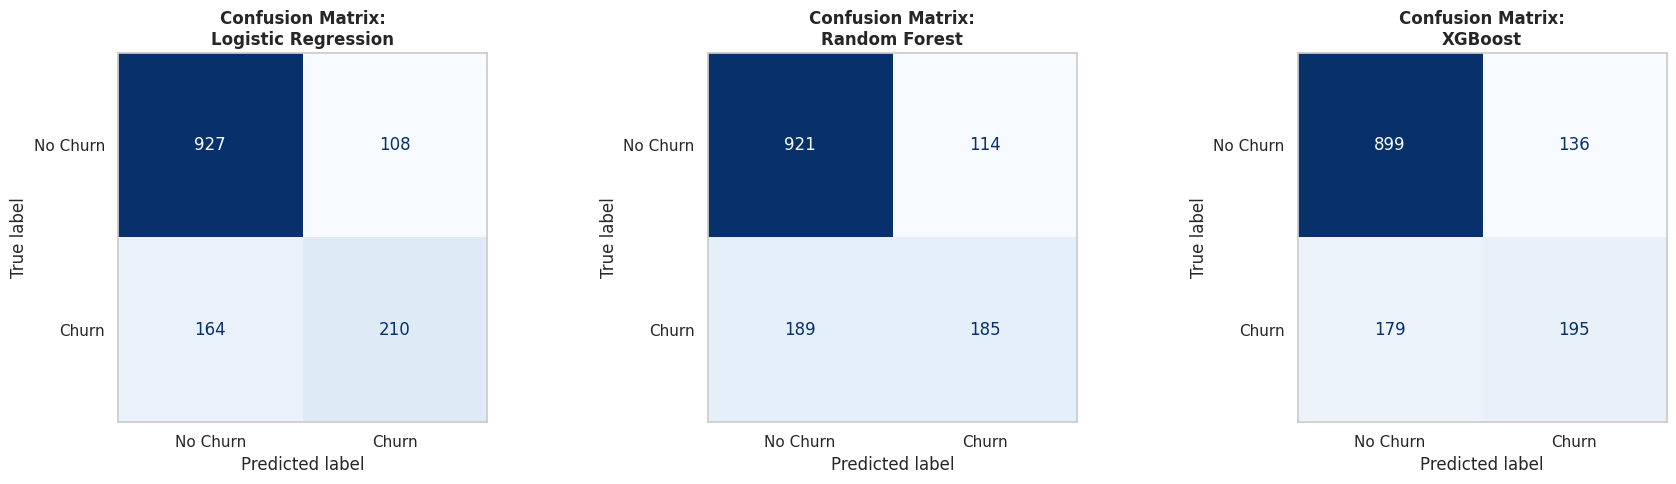

/usr/local/lib/python3.13/dist-packages/xgboost/training.py:200: UserWarning: [10:45:45] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


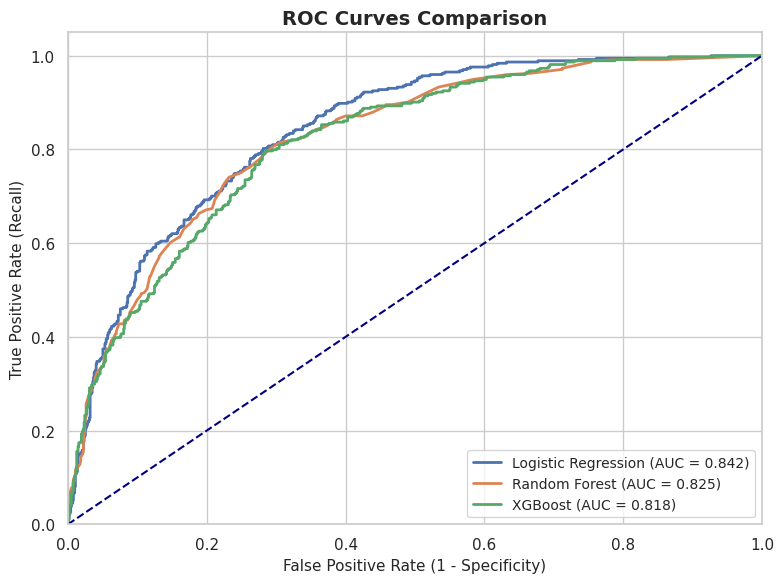

/tmp/ipykernel_5896/2300718484.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=top_features, palette=colors)


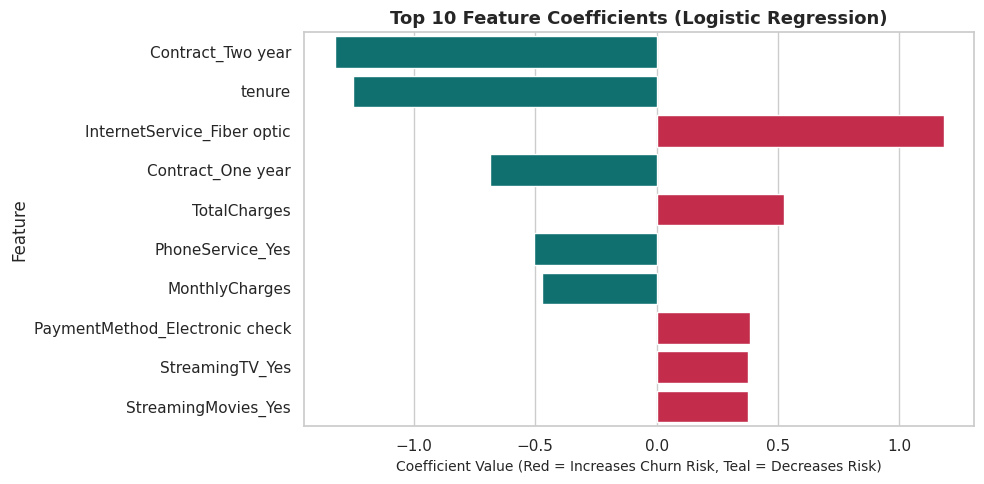

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

# Style graphique professionnel
sns.set_theme(style="whitegrid")
fig_path = "ml_models_evaluation.png"

# -------------------------------------------------------------------------
# 1. MATRICES DE CONFUSION (Side-by-Side)
# -------------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (name, model) in enumerate(models.items()):
    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', model)])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
    disp.plot(ax=axes[idx], cmap='Blues', values_format='d', colorbar=False)
    axes[idx].set_title(f'Confusion Matrix:\n{name}', fontsize=12, fontweight='bold')
    axes[idx].grid(False)

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=300)
plt.show()

# -------------------------------------------------------------------------
# 2. COURBES ROC (Comparison Plot)
# -------------------------------------------------------------------------
plt.figure(figsize=(8, 6))

for name, model in models.items():
    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', model)])
    pipeline.fit(X_train, y_train)
    y_proba = pipeline.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=11)
plt.ylabel('True Positive Rate (Recall)', fontsize=11)
plt.title('ROC Curves Comparison', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=10)
plt.tight_layout()
plt.savefig('roc_curves_comparison.png', dpi=300)
plt.show()

# -------------------------------------------------------------------------
# 3. FEATURE IMPORTANCE (Logistic Regression Top Coefficients)
# -------------------------------------------------------------------------
# Extraction des noms de colonnes après One-Hot Encoding
lr_pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', models['Logistic Regression'])])
lr_pipeline.fit(X_train, y_train)

cat_feature_names = lr_pipeline.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(cat_cols)
all_feature_names = list(num_cols) + list(cat_feature_names)

coefs = lr_pipeline.named_steps['classifier'].coef_[0]
feature_importance = pd.DataFrame({'Feature': all_feature_names, 'Coefficient': coefs})
feature_importance['Absolute_Coef'] = feature_importance['Coefficient'].abs()
top_features = feature_importance.sort_values(by='Absolute_Coef', ascending=False).head(10)

plt.figure(figsize=(10, 5))
colors = ['crimson' if c > 0 else 'teal' for c in top_features['Coefficient']]
sns.barplot(x='Coefficient', y='Feature', data=top_features, palette=colors)
plt.title('Top 10 Feature Coefficients (Logistic Regression)', fontsize=13, fontweight='bold')
plt.xlabel('Coefficient Value (Red = Increases Churn Risk, Teal = Decreases Risk)', fontsize=10)
plt.tight_layout()
plt.savefig('top_features_importance.png', dpi=300)
plt.show()